<h1 align="center"><b>DinoSkyNet - Meteor Detection System</b></h1>
<h3 align="center"><b>Data Analysis and Design</b></h3><br>
<h3 align="center"><b>Joel Sierra</b></h3><br>
<h4 align="center"><b>Date: 2025-12-17</b></h4><br>

### **Path Setup**

In [1]:
from pathlib import Path
import random
import sys
import os

# Reproducibility
SEED = 42
random.seed(SEED)

# === Define Storage Paths ===
# Root Path
ROOT = Path(".").resolve().parent

# Core paths
SRC = ROOT / "src"
DATA_SRC = ROOT / "data" / "111_days" / "processed_data"
TRAIN = DATA_SRC / "train"
TEST  =  DATA_SRC / "test"
MODEL_DIR = ROOT / "models"
DATASET_DIR = DATA_SRC / "production_datasets"


# Analysis paths
NOTEBOOK_DIR = ROOT / "notebooks"
NOTE_OUT_DIR = NOTEBOOK_DIR / "outputs"

# Create folders if missing
for d in [SRC, DATA_SRC, MODEL_DIR, DATASET_DIR, NOTEBOOK_DIR, NOTE_OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Dino-SkyNet root:", SRC)
print("Data sources:", DATA_SRC.exists())
print("Notebooks:", NOTEBOOK_DIR)

Dino-SkyNet root: /app/src
Data sources: True
Notebooks: /app/notebooks


### **Load Data Sources**

In [2]:
import pandas as pd

COLUMNS = ["frame", "object_id", "x_km", "y_km", "z_km", "wind_x", "wind_y"]

scene_dfs = []
bad_files = []

# Load individual scene text files as DFs
for txt_path in sorted(TRAIN.glob("*.txt")):
    scene_id = int(txt_path.stem)  # Extract scene id

    try:
        df = pd.read_csv(
            txt_path,
            sep=r"\s+",
            header=None,
            names=COLUMNS,
            engine="python",
            comment="#",
        )

        # Import validation
        if df.shape[1] != len(COLUMNS):
            bad_files.append((txt_path.name, df.shape))
            continue

        # Add scene id
        df["scene_id"] = scene_id
        scene_dfs.append(df)

    except Exception as e:
        bad_files.append((txt_path.name, str(e)))

if not scene_dfs:
    raise ValueError("No scene files were loaded.")

train_df = pd.concat(scene_dfs, ignore_index=True)

# Sanity Check
print("Total scenes loaded into main df:", len(scene_dfs))
print("Total main df rows:", train_df.shape[0])
print("Total bad files:", len(bad_files))

if bad_files:
    for item in bad_files[:5]:
        print(" -", item)

train_df.head()

Total scenes loaded into main df: 2230
Total main df rows: 1917017
Total bad files: 0


/tmp/ipykernel_20/570270496.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat(scene_dfs, ignore_index=True)


,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id
0,0,10995703,-4.079537,0.056573,0.57912,0.507009,3.56521,1
1,1,10995703,-4.026575,0.056876,0.56388,0.507009,3.56521,1
2,2,10995703,-3.973612,0.057180,0.54864,0.507009,3.56521,1
3,3,10995703,-3.941283,0.056877,0.54864,0.507009,3.56521,1
4,4,10995703,-3.883392,0.055276,0.54864,0.507009,3.56521,1


#### **Analyze Single Scene**

In [3]:
scene_id = 42

scene_df = (
    train_df[train_df["scene_id"] == scene_id]
    .sort_values("frame")
    .reset_index(drop=True)
)

scene_df.info()
print()
scene_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   frame      1598 non-null   object 
 1   object_id  1598 non-null   object 
 2   x_km       1598 non-null   float64
 3   y_km       1598 non-null   float64
 4   z_km       1598 non-null   float64
 5   wind_x     1598 non-null   float64
 6   wind_y     1598 non-null   float64
 7   scene_id   1598 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 100.0+ KB



,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id
0,28223,10561439,0.816127,0.206101,0.0000,-5.360128,-4.81042,42
1,28223,10979952,0.876138,-0.020933,0.3048,-5.360128,-4.81042,42
2,28224,10979952,0.901978,-0.020672,0.3048,-5.360128,-4.81042,42
3,28224,10561439,0.815176,0.206995,0.0000,-5.360128,-4.81042,42
4,28225,10561439,0.810992,0.207778,0.0000,-5.360128,-4.81042,42


In [5]:
# Number of unique objects in scene
scene_objects = scene_df["object_id"].unique()

print("Number of unique objects in scene:", len(scene_objects))
display(pd.DataFrame(scene_objects, columns=["Unique Object IDs"]))

Number of unique objects in scene: 5


,Unique Object IDs
0,10561439
1,10979952
2,10764272
3,10942561
4,11374945


In [6]:
# Estimate ADS-B reading range
print("X range:", train_df["x_km"].min(), "to", train_df["x_km"].max())
print("Y range:", train_df["y_km"].min(), "to", train_df["y_km"].max())

X range: -4.131952644032317 to 5.866638491784573
Y range: -4.890183759926705 to 5.102012085564506


### **Plot Trajectory of Single Object**

In [8]:
# Grab object in selected df
obj_id = scene_df["object_id"].unique()[3]

# Filter for object and build df
obj_df = scene_df[scene_df["object_id"] == obj_id]

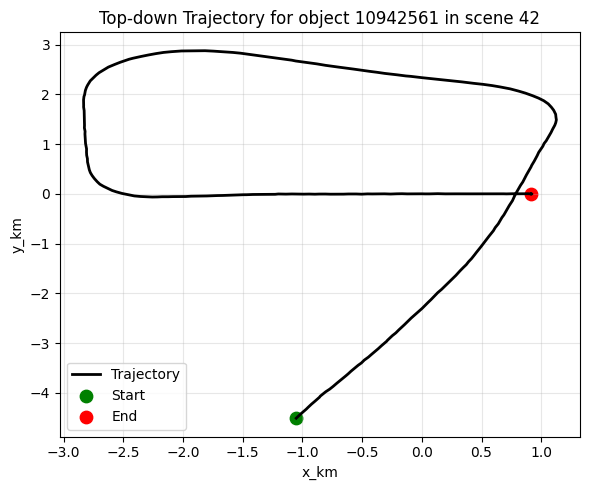

In [9]:
# Plot Top-Down Trajectory
import matplotlib.pyplot as plt

# Sort scene by frame
obj_df = obj_df.sort_values("frame")

# Grab x and y values
x = obj_df["x_km"]
y = obj_df["y_km"]

plt.figure(figsize=(6, 5))

# Plot trajectory
plt.plot(x, y, linewidth=2, color="black", label="Trajectory")

# Plot start and end locations
plt.scatter(x.iloc[0], y.iloc[0], s=80, color="green", label="Start")
plt.scatter(x.iloc[-1], y.iloc[-1], s=80, color="red", label="End")

plt.xlabel("x_km")
plt.ylabel("y_km")
plt.title(f"Top-down Trajectory for object {obj_id} in scene {scene_id}")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

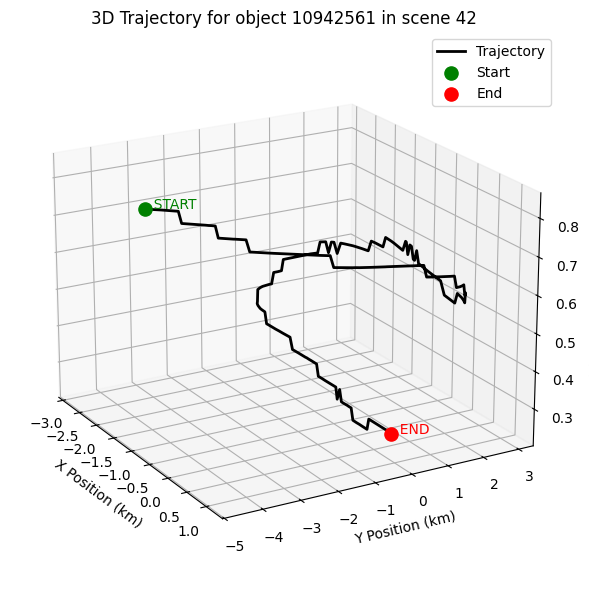

In [10]:
# Plot 3D Trajectory
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# grab positions
x = obj_df["x_km"]
y = obj_df["y_km"]
z = obj_df["z_km"]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot 3D Trajectory
ax.plot(x, y, z, linewidth=2, color="black", label="Trajectory")

# Add starting and ending points to plot
ax.scatter(x.iloc[0], y.iloc[0], z.iloc[0], color="green", s=90, label="Start")
ax.scatter(x.iloc[-1], y.iloc[-1], z.iloc[-1], color="red", s=90, label="End")

# Add labels directly on the points
ax.text(x.iloc[0], y.iloc[0], z.iloc[0], "  START", color="green")
ax.text(x.iloc[-1], y.iloc[-1], z.iloc[-1], "  END", color="red")

ax.set_xlabel("X Position (km)")
ax.set_ylabel("Y Position (km)")
ax.set_zlabel("Altitude Z (km)")
ax.set_title(f"3D Trajectory for object {obj_id} in scene {scene_id}")

# Set Camera angle
ax.view_init(elev=20, azim=-30)

ax.legend()
plt.tight_layout()
plt.show()

### **Plot Trajectory of all Objects in Scene**

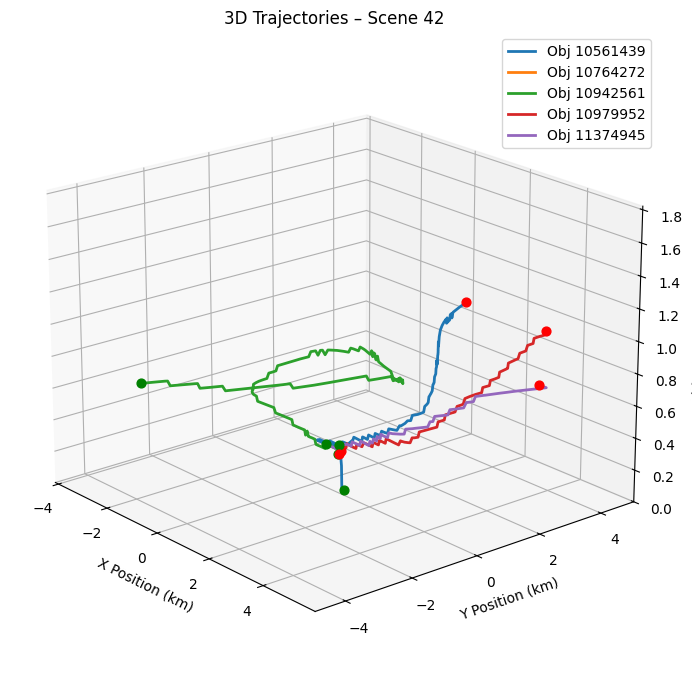

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Grab ADS-B estimated reading limits
x_min, x_max = train_df["x_km"].min(), train_df["x_km"].max()
y_min, y_max = train_df["y_km"].min(), train_df["y_km"].max()
z_min, z_max = train_df["z_km"].min(), train_df["z_km"].max()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Color map for objects
obj_ids = scene_df["object_id"].unique()
colors = cm.tab10(range(len(obj_ids)))

# Plot objects in scene
for i, (obj_id, obj_data) in enumerate(scene_df.groupby("object_id")):
    obj_data = obj_data.sort_values("frame")  # Sort by frame

    # grab positions
    x = obj_data["x_km"]
    y = obj_data["y_km"]
    z = obj_data["z_km"]

    # Assign color to object
    color = colors[i % len(colors)]

    # Plot Trajectory
    ax.plot(x, y, z, color=color, linewidth=2, label=f"Obj {obj_id}")

    # Plot start and end points
    ax.scatter(x.iloc[0], y.iloc[0], z.iloc[0], color="green", s=40)
    ax.scatter(x.iloc[-1], y.iloc[-1], z.iloc[-1], color="red", s=40)

# Set axis limits per ADS-B reading range
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

# Graph labels
ax.set_xlabel("X Position (km)")
ax.set_ylabel("Y Position (km)")
ax.set_zlabel("Altitude (km)")
ax.set_title(f"3D Trajectories – Scene {scene_id}")

# Set camera angle
ax.view_init(elev=20, azim=-40)


ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Check scenes for object overlap
scene_41 = train_df[train_df["scene_id"] == 41]
scene_42 = train_df[train_df["scene_id"] == 42]
scene_43 = train_df[train_df["scene_id"] == 43]

ids_41 = set(scene_41["object_id"].unique())
ids_42 = set(scene_42["object_id"].unique())
ids_43 = set(scene_43["object_id"].unique())

print("41 and 42 overlap:", ids_41.intersection(ids_42))
print("42 and 43 overlap:", ids_42.intersection(ids_43))
print("41 and 43 overlap:", ids_41.intersection(ids_43))

41 and 42 overlap: {10764272}
42 and 43 overlap: set()
41 and 43 overlap: set()


### **Motion Feature Engineering**

#### **Sort by Object and Time**

We ensure each trajectory is ordered correctly:

$$
(x_t, y_t, z_t) \rightarrow (x_{t+1}, y_{t+1}, z_{t+1})
$$

This allows us to compute position differences between consecutive frames.

In [12]:
# Make a copy of scend df to prototype
scene_features_df = scene_df.sort_values(["object_id", "frame"]).copy()
group_cols = ["object_id"]  # Grab objects to derive features

scene_features_df.head()

,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id
0,28223,10561439,0.816127,0.206101,0.0,-5.360128,-4.81042,42
3,28224,10561439,0.815176,0.206995,0.0,-5.360128,-4.81042,42
4,28225,10561439,0.810992,0.207778,0.0,-5.360128,-4.81042,42
7,28226,10561439,0.811051,0.207961,0.0,-5.360128,-4.81042,42
8,28227,10561439,0.811111,0.208144,0.0,-5.360128,-4.81042,42


### Compute Position Differences (First-Order)

We compute changes in position between consecutive frames:

$$
\Delta x_t = x_t - x_{t-1}, \quad
\Delta y_t = y_t - y_{t-1}, \quad
\Delta z_t = z_t - z_{t-1}
$$

From the README we know data is sampled at 1 Hz:

$$
v_x = \frac{\Delta x}{\Delta t} = \Delta x
$$

So **position differences directly represent velocity**.

In [13]:
scene_features_df["dx"] = scene_features_df.groupby(group_cols)["x_km"].diff()
scene_features_df["dy"] = scene_features_df.groupby(group_cols)["y_km"].diff()
scene_features_df["dz"] = scene_features_df.groupby(group_cols)["z_km"].diff()

scene_features_df[["dx", "dy", "dz"]].head()

,dx,dy,dz
0,NaN,NaN,NaN
3,-0.000951,0.000895,0.0
4,-0.004185,0.000783,0.0
7,0.000060,0.000183,0.0
8,0.000060,0.000183,0.0


### Add Velocity Components

Each frame now contains velocity too:

$$
v_t = (v_x, v_y, v_z)
$$

In [15]:
scene_features_df["vx_km_s"] = scene_features_df["dx"]
scene_features_df["vy_km_s"] = scene_features_df["dy"]
scene_features_df["vz_km_s"] = scene_features_df["dz"]

scene_features_df[["vx_km_s", "vy_km_s", "vz_km_s"]].head()

,vx_km_s,vy_km_s,vz_km_s
0,NaN,NaN,NaN
3,-0.000951,0.000895,0.0
4,-0.004185,0.000783,0.0
7,0.000060,0.000183,0.0
8,0.000060,0.000183,0.0


### Compute Speed (Magnitude of Velocity)

Horizontal speed:

$$
v_{xy} = \sqrt{v_x^2 + v_y^2}
$$

Full 3D speed:

$$
v = \sqrt{v_x^2 + v_y^2 + v_z^2}
$$

In [16]:
import numpy as np

scene_features_df["horizontal_speed_km_s"] = np.sqrt(
    scene_features_df["vx_km_s"]**2 + scene_features_df["vy_km_s"]**2
)

scene_features_df["speed_3d_km_s"] = np.sqrt(
    scene_features_df["vx_km_s"]**2
    + scene_features_df["vy_km_s"]**2
    + scene_features_df["vz_km_s"]**2
)

scene_features_df[["horizontal_speed_km_s", "speed_3d_km_s"]].head()

,horizontal_speed_km_s,speed_3d_km_s
0,NaN,NaN
3,0.001306,0.001306
4,0.004257,0.004257
7,0.000192,0.000192
8,0.000192,0.000192


### Compute Acceleration (Second-Order Differences)

We compute changes in velocity:

$$
a_x = v_{x,t} - v_{x,t-1}
$$

Full acceleration magnitude:

$$
a = \sqrt{a_x^2 + a_y^2 + a_z^2}
$$

In [17]:
scene_features_df["ax_km_s2"] = scene_features_df.groupby(group_cols)["vx_km_s"].diff()
scene_features_df["ay_km_s2"] = scene_features_df.groupby(group_cols)["vy_km_s"].diff()
scene_features_df["az_km_s2"] = scene_features_df.groupby(group_cols)["vz_km_s"].diff()

scene_features_df["accel_3d_km_s2"] = np.sqrt(
    scene_features_df["ax_km_s2"]**2
    + scene_features_df["ay_km_s2"]**2
    + scene_features_df["az_km_s2"]**2
)

scene_features_df[["ax_km_s2", "ay_km_s2", "az_km_s2", "accel_3d_km_s2"]].head()

,ax_km_s2,ay_km_s2,az_km_s2,accel_3d_km_s2
0,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,-3.233591e-03,-1.117202e-04,0.0,3.235521e-03
7,4.244215e-03,-6.004278e-04,0.0,4.286475e-03
8,1.110223e-16,2.775558e-17,0.0,1.144392e-16


### Step 6 — Descent Rate

We define descent rate as:

$$
\text{descent rate} = -v_z
$$

So:
- Positive → moving downward  
- Negative → climbing  

In [18]:
scene_features_df["descent_rate_km_s"] = -scene_features_df["vz_km_s"]

scene_features_df[["vz_km_s", "descent_rate_km_s"]].head()

,vz_km_s,descent_rate_km_s
0,NaN,NaN
3,0.0,-0.0
4,0.0,-0.0
7,0.0,-0.0
8,0.0,-0.0


### Step 7 — Handling Missing Values

The first frame per object has no previous timestep:

$$
\text{diff} \rightarrow \text{NaN}
$$

We replace these with 0 for consistency.

In [19]:
scene_features_df = scene_features_df.fillna(0)

scene_features_df.head()

/tmp/ipykernel_18/3840179723.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scene_features_df = scene_features_df.fillna(0)


,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id,dx,dy,...,vx_km_s,vy_km_s,vz_km_s,horizontal_speed_km_s,speed_3d_km_s,ax_km_s2,ay_km_s2,az_km_s2,accel_3d_km_s2,descent_rate_km_s
0,28223,10561439,0.816127,0.206101,0.0,-5.360128,-4.81042,42,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0
3,28224,10561439,0.815176,0.206995,0.0,-5.360128,-4.81042,42,-0.000951,0.000895,...,-0.000951,0.000895,0.0,0.001306,0.001306,0.000000e+00,0.000000e+00,0.0,0.000000e+00,-0.0
4,28225,10561439,0.810992,0.207778,0.0,-5.360128,-4.81042,42,-0.004185,0.000783,...,-0.004185,0.000783,0.0,0.004257,0.004257,-3.233591e-03,-1.117202e-04,0.0,3.235521e-03,-0.0
7,28226,10561439,0.811051,0.207961,0.0,-5.360128,-4.81042,42,0.000060,0.000183,...,0.000060,0.000183,0.0,0.000192,0.000192,4.244215e-03,-6.004278e-04,0.0,4.286475e-03,-0.0
8,28227,10561439,0.811111,0.208144,0.0,-5.360128,-4.81042,42,0.000060,0.000183,...,0.000060,0.000183,0.0,0.000192,0.000192,1.110223e-16,2.775558e-17,0.0,1.144392e-16,-0.0


Object ID: 11374945
Number of frames: 220

              frame  speed_3d_m_s  horizontal_speed_m_s      vz_m_s  \
count    220.000000    220.000000            220.000000  220.000000   
mean   28822.500000     31.632382             31.007710    2.078182   
std       63.652704     19.898498             19.376380    7.448203   
min    28713.000000      0.000000              0.000000    0.000000   
25%    28767.750000      4.060912              4.060912    0.000000   
50%    28822.500000     37.272079             36.672912    0.000000   
75%    28877.250000     45.345420             43.694874    0.000000   
max    28932.000000     89.036358             89.036358   30.480000   

       descent_rate_m_s  accel_3d_m_s2  
count        220.000000   2.200000e+02  
mean          -2.078182   1.056472e+01  
std            7.448203   1.383602e+01  
min          -30.480000   0.000000e+00  
25%           -0.000000   8.881784e-13  
50%           -0.000000   4.616907e+00  
75%            0.000000   1.63

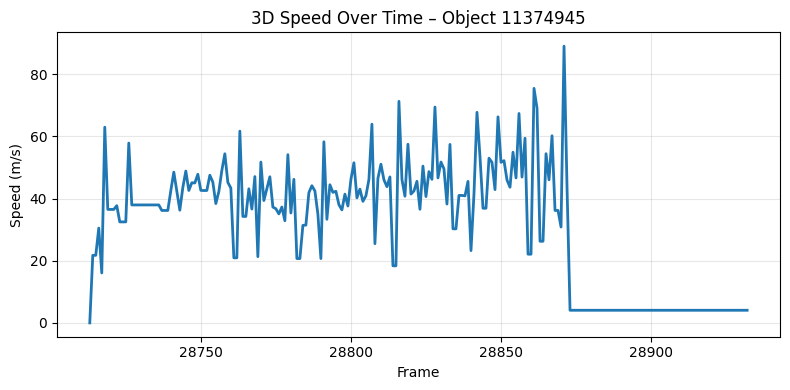

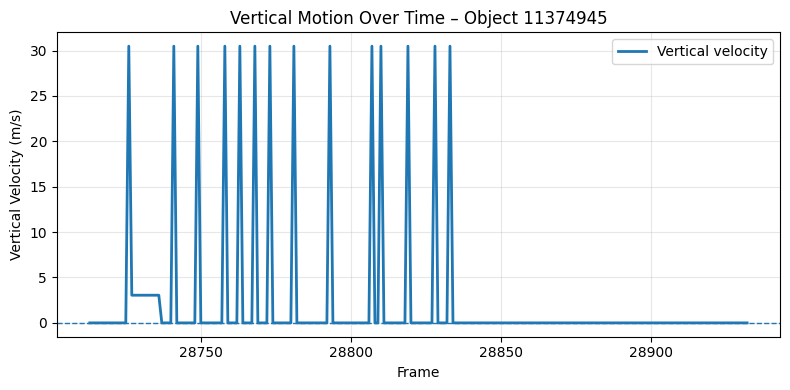

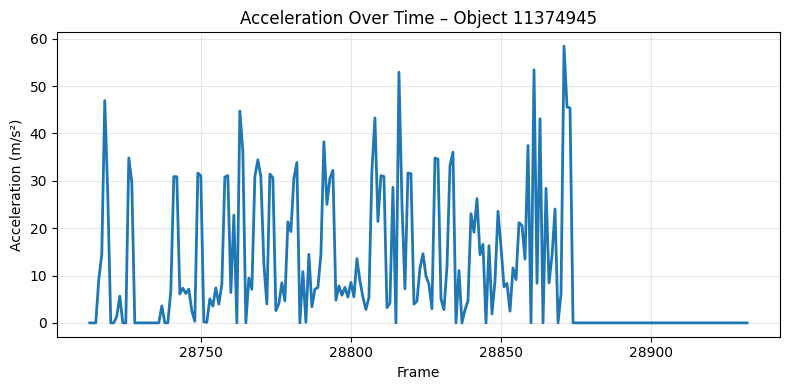

,object_id,mean_speed_m_s,max_speed_m_s,mean_accel_m_s2,max_descent_rate_m_s,num_frames
2,10942561,47.511360,110.181432,16.977547,30.480000,361
4,11374945,31.632382,89.036358,10.564718,0.000000,220
0,10561439,16.041991,87.025181,6.460615,30.480000,669
3,10979952,26.032704,77.896201,10.219383,0.123791,286
1,10764272,0.022328,0.927807,0.014862,0.000000,62


In [20]:
import matplotlib.pyplot as plt

# Make a copy for visualization with easier units
viz_df = scene_features_df.copy()

# Convert km/s to m/s
viz_df["speed_3d_m_s"] = viz_df["speed_3d_km_s"] * 1000
viz_df["horizontal_speed_m_s"] = viz_df["horizontal_speed_km_s"] * 1000
viz_df["vz_m_s"] = viz_df["vz_km_s"] * 1000
viz_df["descent_rate_m_s"] = viz_df["descent_rate_km_s"] * 1000

# Convert km/s^2 to m/s^2
viz_df["accel_3d_m_s2"] = viz_df["accel_3d_km_s2"] * 1000

# Pick one object to inspect
target_obj = obj_id
obj_viz_df = viz_df[viz_df["object_id"] == target_obj].sort_values("frame")

print("Object ID:", target_obj)
print("Number of frames:", len(obj_viz_df))
print()
print(obj_viz_df[
    [
        "frame",
        "speed_3d_m_s",
        "horizontal_speed_m_s",
        "vz_m_s",
        "descent_rate_m_s",
        "accel_3d_m_s2",
    ]
].describe())

# Speed over time
plt.figure(figsize=(8, 4))
plt.plot(obj_viz_df["frame"], obj_viz_df["speed_3d_m_s"], linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Speed (m/s)")
plt.title(f"3D Speed Over Time – Object {target_obj}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Vertical velocity / descent rate over time
plt.figure(figsize=(8, 4))
plt.plot(obj_viz_df["frame"], obj_viz_df["vz_m_s"], linewidth=2, label="Vertical velocity")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Frame")
plt.ylabel("Vertical Velocity (m/s)")
plt.title(f"Vertical Motion Over Time – Object {target_obj}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Acceleration over time
plt.figure(figsize=(8, 4))
plt.plot(obj_viz_df["frame"], obj_viz_df["accel_3d_m_s2"], linewidth=2)
plt.xlabel("Frame")
plt.ylabel("Acceleration (m/s²)")
plt.title(f"Acceleration Over Time – Object {target_obj}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compare all objects in scene by max/mean speed
object_feature_summary = (
    viz_df.groupby("object_id")
    .agg(
        mean_speed_m_s=("speed_3d_m_s", "mean"),
        max_speed_m_s=("speed_3d_m_s", "max"),
        mean_accel_m_s2=("accel_3d_m_s2", "mean"),
        max_descent_rate_m_s=("descent_rate_m_s", "max"),
        num_frames=("frame", "count"),
    )
    .reset_index()
    .sort_values("max_speed_m_s", ascending=False)
)

display(object_feature_summary)

---
## FOR REFERENCE: Visualize Numeric Features w/Histogram

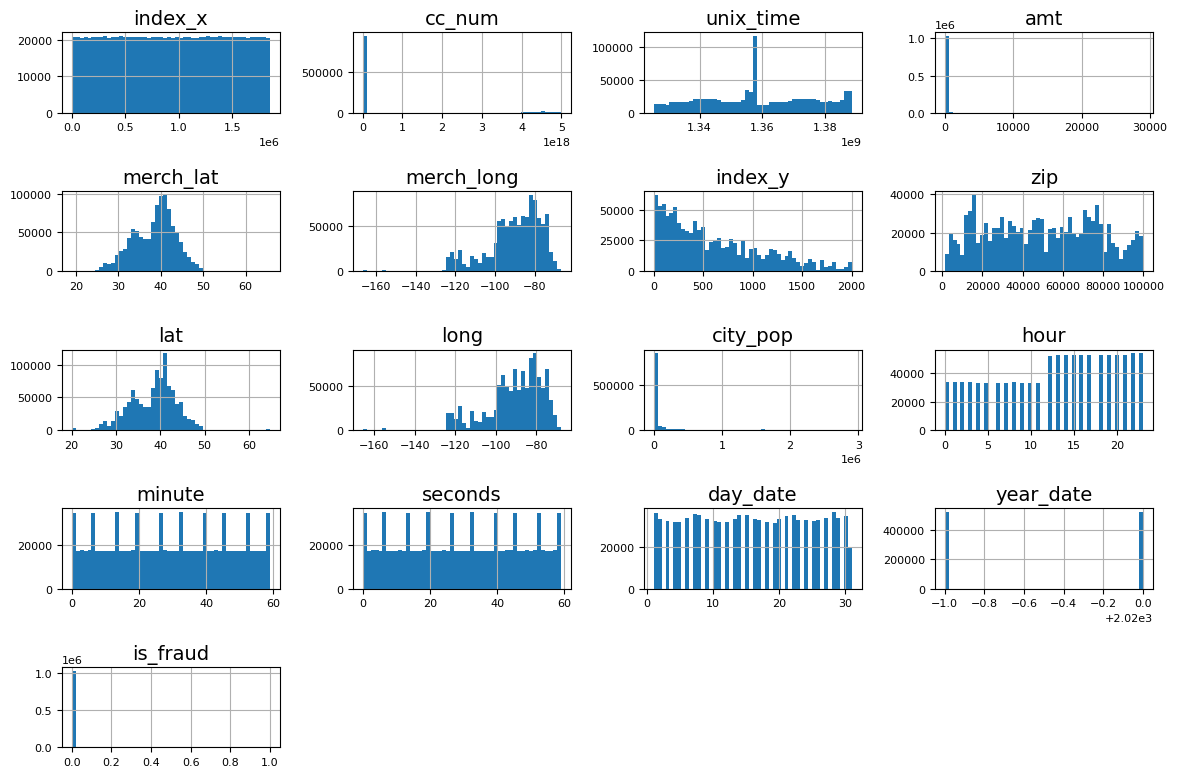

In [37]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)

train_df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [38]:
# Drop features with no predictive value
drop_features = ['index_x', 'index_y', 'minute', 'seconds', 'day_date', 'year_date', 'unix_time']

##### Visualize Categorical Features

Categorical columns: ['merchant', 'category', 'first', 'last', 'sex', 'street', 'city', 'state', 'job', 'dob', 'day_of_week', 'month_date']

Cardinality:


,n_unique
street,750
dob,748
city,697
merchant,694
job,563
last,413
first,308
state,50
category,29
month_date,12



=== merchant ===


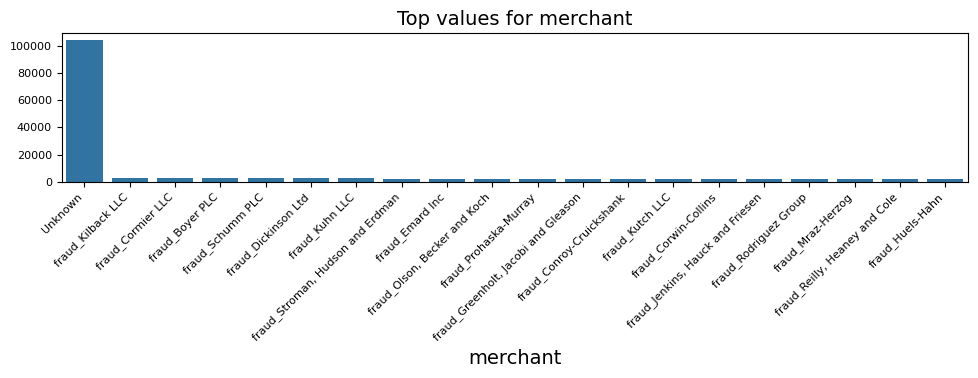


=== category ===


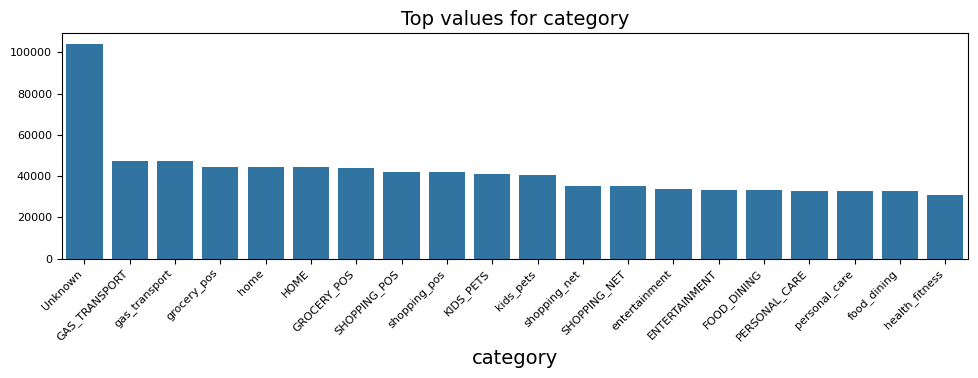


=== first ===


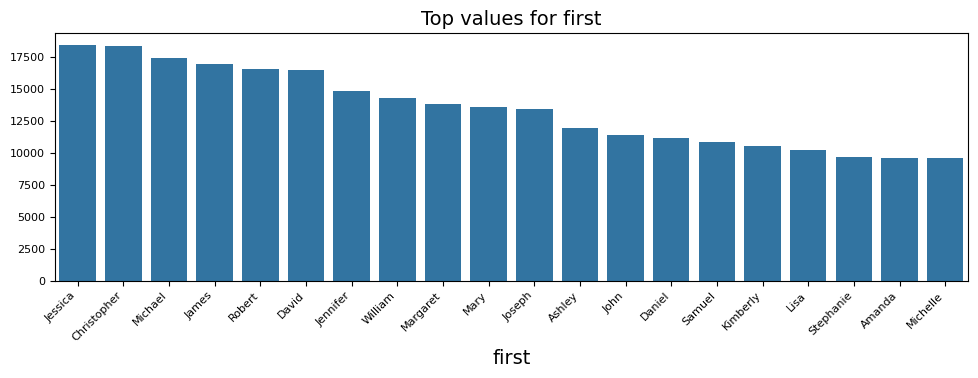


=== last ===


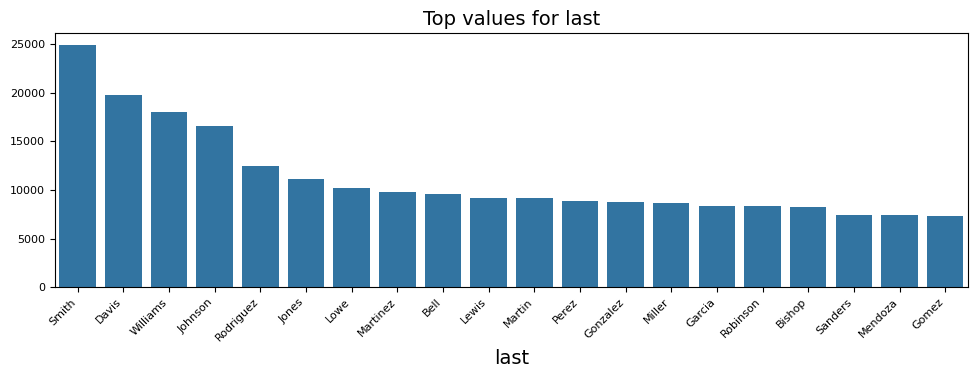


=== sex ===


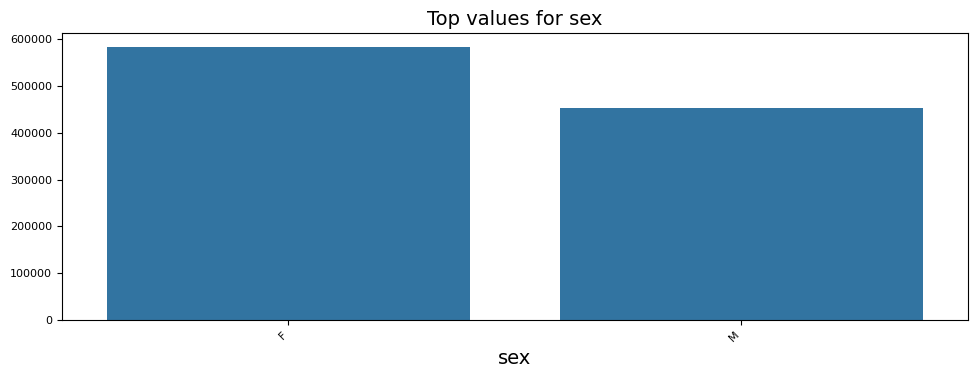


=== street ===


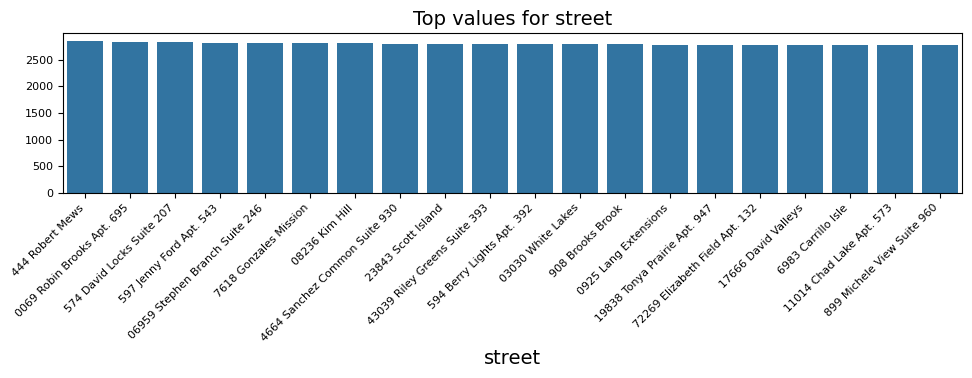


=== city ===


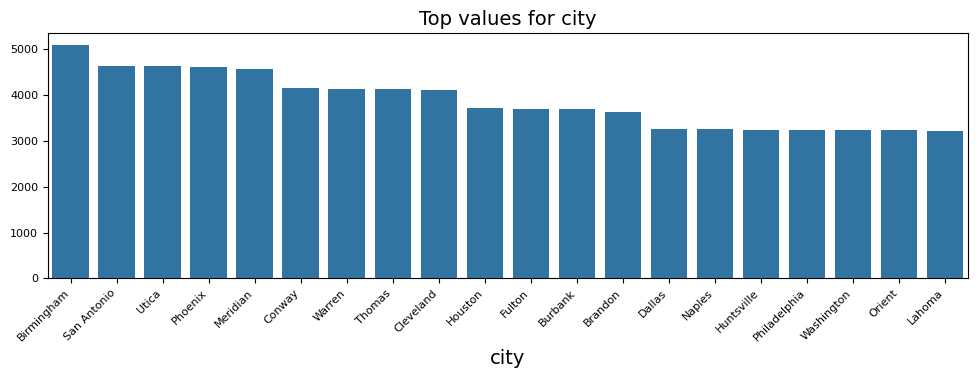


=== state ===


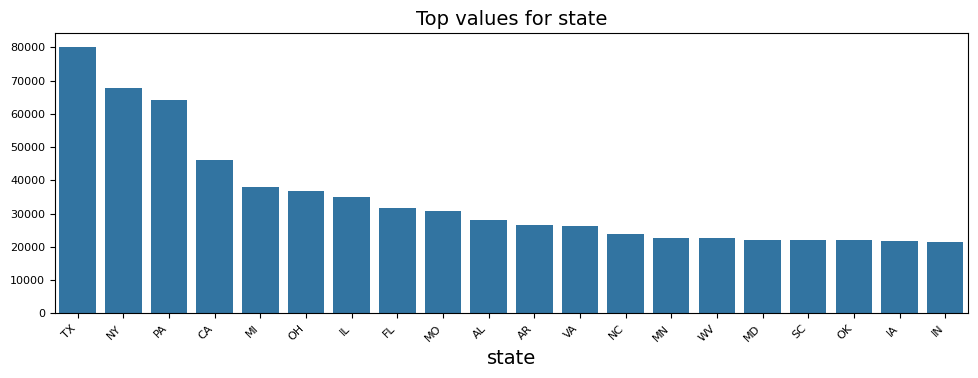


=== job ===


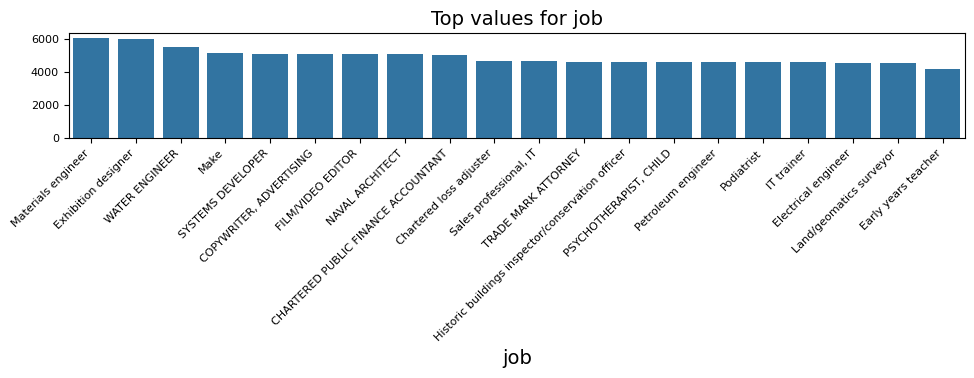


=== dob ===


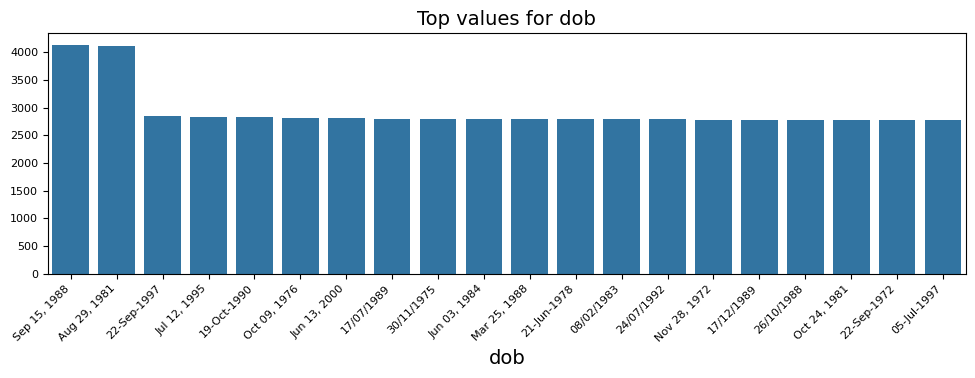


=== day_of_week ===


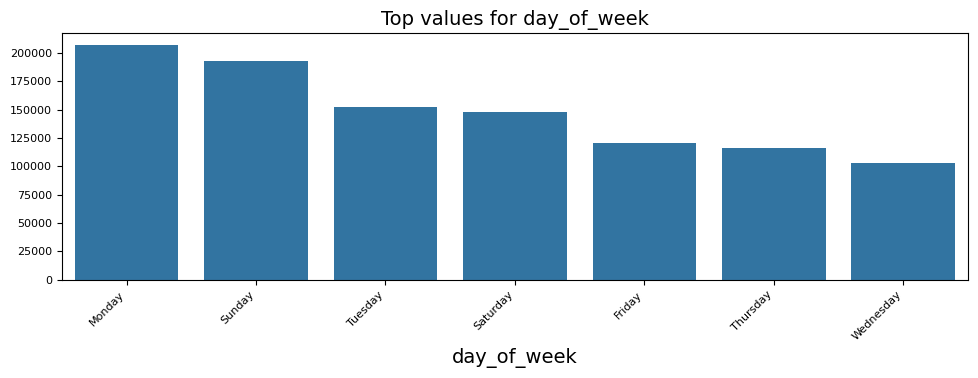


=== month_date ===


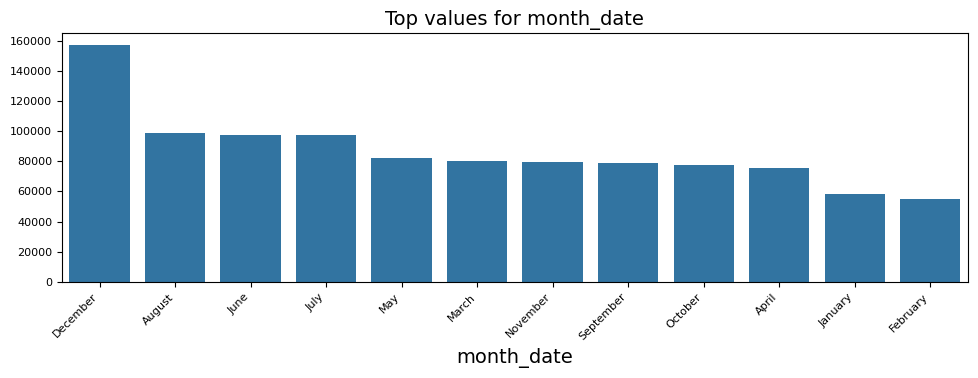

In [39]:
import matplotlib.pyplot as plt

# Identify categorical columns (object or category dtype)
cat_cols = train_df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", cat_cols)

# Cardinality summary
cardinality = train_df[cat_cols].nunique().sort_values(ascending=False)
print("\nCardinality:")
display(cardinality.to_frame("n_unique"))

# Value counts plots for each categorical feature
for col in cat_cols:
    print(f"\n=== {col} ===")
    plt.figure(figsize=(10, 4))

    # Show top categories only (avoids unreadable plots)
    top_vals = train_df[col].value_counts().head(20)

    sns.barplot(x=top_vals.index.astype(str), y=top_vals.values)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top values for {col}")
    plt.tight_layout()
    plt.show()

In [40]:
# Drop features with high cardinality and personal information (no generalization value across different customers and sensitive info)
cat_drop = ['first', 'last', 'street']

#### Prototype Preprocessing Pipeline

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

# Feature groups (after drops + dob -> age)
num_cols = [
    "cc_num", "amt", "zip", "city_pop",
    "lat", "long", "merch_lat", "merch_long",
    "hour", "age",  # age will be created from dob
]

cat_low = ["category", "sex", "day_of_week", "month_date"]   # low cardinality features (few unique values)
cat_high = ["merchant", "city", "state", "job"]              # high cardinality features (many unique values)

# Age helper: convert dob -> age and drop unwanted columns
def add_age_and_drop(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    # dob -> age (simple reference date)
    if "dob" in X.columns:
        dob = pd.to_datetime(X["dob"], errors="coerce")
        ref_date = pd.Timestamp("2020-01-01")
        X["age"] = (ref_date - dob).dt.days / 365.25
        X = X.drop(columns=["dob"])

    # drop unwanted numeric + categorical features
    X = X.drop(columns=drop_features + cat_drop, errors="ignore")
    return X

preprocess = Pipeline(
    steps=[
        ("prep_df", FunctionTransformer(add_age_and_drop, validate=False)),
        ("features", ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), num_cols),
                ("cat_low", OneHotEncoder(handle_unknown="ignore"), cat_low),
                ("cat_high", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ), cat_high),
            ],
            remainder="drop",
        )),
    ]
)

##### Preprocess Transform Training Dataset

In [59]:
# Fit the preprocessing pipeline on X_train
preprocess.fit(X_train)

# Transform the training features
X_train_proc = preprocess.transform(X_train)

##### Verify Preprocessing Pipeline

In [60]:
print("Raw X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_proc.shape)

print(type(X_train_proc))

Raw X_train shape: (1038010, 28)
Processed X_train shape: (1038010, 64)
<class 'scipy.sparse._csr.csr_matrix'>


Age summary:
 count    325304.000000
mean         45.573745
std          16.425699
min          16.654346
25%          32.177960
50%          44.032854
75%          54.735113
max          93.472964
Name: age, dtype: float64


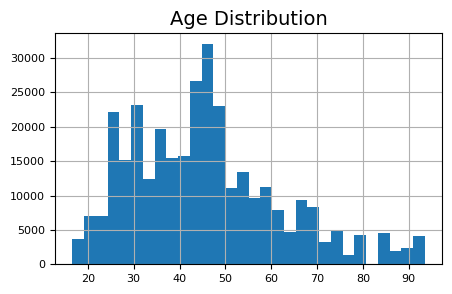


Columns after 'dob' feature transformation:
['age', 'amt', 'category', 'cc_num', 'city', 'city_pop', 'day_of_week', 'hour', 'job', 'lat', 'long', 'merch_lat', 'merch_long', 'merchant', 'month_date', 'sex', 'state', 'zip']

Has 'dob'? False
Has 'age'? True


In [61]:
# New 'age' feature sanity check
X_debug = add_age_and_drop(X_train.copy())
print("Age summary:\n", X_debug["age"].describe())

X_debug["age"].hist(bins=30, figsize=(5,3))
plt.title("Age Distribution")
plt.show()

# Check that dob -> age worked in the internal transformer
X_debug = add_age_and_drop(X_train.copy())

print("\nColumns after 'dob' feature transformation:")
print(sorted(X_debug.columns))

print("\nHas 'dob'?", "dob" in X_debug.columns)
print("Has 'age'?", "age" in X_debug.columns)


#### Test Preprocessing Module

In [64]:
from securebank.modules.data.preprocessing import SecureBankPreprocessor

pre = SecureBankPreprocessor()
pre.fit(X_train)

X_train_proc = pre.transform(X_train)
X_val_proc   = pre.transform(X_val)
X_test_proc  = pre.transform(X_test)

print("Train/Val/Test shapes after preprocessing:")
print(X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)

/app/securebank/modules/data/preprocessing.py:68: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dob = pd.to_datetime(out["dob"], errors="coerce")


Train/Val/Test shapes after preprocessing:
(1038010, 64) (222431, 64) (222431, 64)
